# Dataset Analysis - WBCAtt

## Project
Explainable White Blood Cell Morphology Analysis using MAL-ViT

## Purpose

The purpose of this notebook is to understand the WBCAtt dataset before building the
training pipeline.

This notebook answers the following questions:

- How many samples exist?
- How many unique images?
- What are the WBC classes?
- What morphology attributes are available?
- Are there missing values?
- Are image paths correct?
- What is the class distribution?
- What is the attribute distribution?
- What is the image resolution?

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from PIL import Image

import os

In [5]:
train_df = pd.read_csv(r"F:\projects\WBC Morphology Analysis using MAL-ViT\pbc_attr_v1_train.csv")

val_df = pd.read_csv(r"F:\projects\WBC Morphology Analysis using MAL-ViT\pbc_attr_v1_val.csv")

test_df = pd.read_csv(r"F:\projects\WBC Morphology Analysis using MAL-ViT\test.csv")

In [6]:
print("="*60)
print("TRAIN")
print(train_df.shape)

print("="*60)
print("VALIDATION")
print(val_df.shape)

print("="*60)
print("TEST")
print(test_df.shape)

TRAIN
(6169, 14)
VALIDATION
(1030, 14)
TEST
(3099, 14)


In [7]:
train_df.columns

Index(['img_name', 'label', 'cell_size', 'cell_shape', 'nucleus_shape',
       'nuclear_cytoplasmic_ratio', 'chromatin_density', 'cytoplasm_vacuole',
       'cytoplasm_texture', 'cytoplasm_colour', 'granule_type',
       'granule_colour', 'granularity', 'path'],
      dtype='object')

In [8]:
train_df.isnull().sum()

img_name                     0
label                        0
cell_size                    0
cell_shape                   0
nucleus_shape                0
nuclear_cytoplasmic_ratio    0
chromatin_density            0
cytoplasm_vacuole            0
cytoplasm_texture            0
cytoplasm_colour             0
granule_type                 0
granule_colour               0
granularity                  0
path                         0
dtype: int64

In [9]:
print(train_df["img_name"].nunique())

6169


In [10]:
total_unique = pd.concat(
    [train_df, val_df, test_df]
)["img_name"].nunique()

print(total_unique)

10298


In [27]:
train_df["label"].value_counts()

label
Neutrophil    1984
Eosinophil    1876
Monocyte       829
Basophil       744
Lymphocyte     736
Name: count, dtype: int64

In [28]:
train_df["label"].value_counts(normalize=True) * 100

label
Neutrophil    32.160804
Eosinophil    30.410115
Monocyte      13.438159
Basophil      12.060302
Lymphocyte    11.930621
Name: proportion, dtype: float64

In [29]:
img = Image.open(train_df.iloc[0]["path"])

print(img.mode)

RGB


In [11]:
train_df["label"].value_counts()

label
Neutrophil    1984
Eosinophil    1876
Monocyte       829
Basophil       744
Lymphocyte     736
Name: count, dtype: int64

<Axes: xlabel='label'>

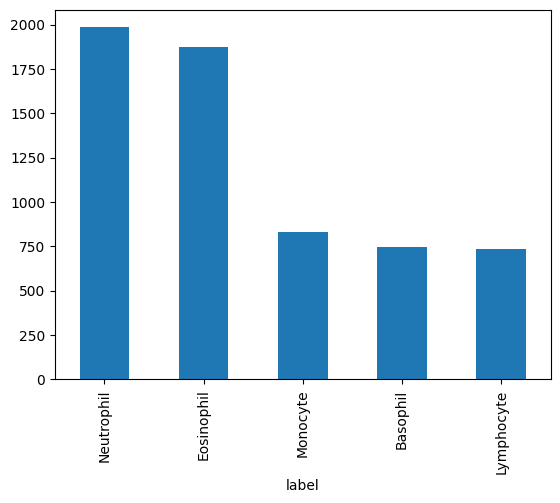

In [12]:
train_df["label"].value_counts().plot(kind="bar")

In [13]:
attributes = [

"cell_size",

"cell_shape",

"nucleus_shape",

"nuclear_cytoplasmic_ratio",

"chromatin_density",

"cytoplasm_vacuole",

"cytoplasm_texture",

"cytoplasm_colour",

"granule_type",

"granule_colour",

"granularity"

]

In [14]:
for attribute in attributes:

    print("="*50)

    print(attribute)

    print(train_df[attribute].value_counts())


cell_size
cell_size
big      3293
small    2876
Name: count, dtype: int64
cell_shape
cell_shape
round        4774
irregular    1395
Name: count, dtype: int64
nucleus_shape
nucleus_shape
segmented-bilobed       1899
unsegmented-band        1587
unsegmented-indented     769
segmented-multilobed     725
unsegmented-round        662
irregular                527
Name: count, dtype: int64
nuclear_cytoplasmic_ratio
nuclear_cytoplasmic_ratio
low     5424
high     745
Name: count, dtype: int64
chromatin_density
chromatin_density
densely    5631
loosely     538
Name: count, dtype: int64
cytoplasm_vacuole
cytoplasm_vacuole
no     5705
yes     464
Name: count, dtype: int64
cytoplasm_texture
cytoplasm_texture
clear      4970
frosted    1199
Name: count, dtype: int64
cytoplasm_colour
cytoplasm_colour
light blue     4693
blue            832
purple blue     644
Name: count, dtype: int64
granule_type
granule_type
small     1987
round     1875
nil       1564
coarse     743
Name: count, dtype: int64
gran

In [15]:
sample = train_df.iloc[0]

sample

img_name                                                       BNE_7323.jpg
label                                                            Neutrophil
cell_size                                                               big
cell_shape                                                            round
nucleus_shape                                              unsegmented-band
nuclear_cytoplasmic_ratio                                               low
chromatin_density                                                   densely
cytoplasm_vacuole                                                        no
cytoplasm_texture                                                     clear
cytoplasm_colour                                                 light blue
granule_type                                                          small
granule_colour                                                         pink
granularity                                                             yes
path        

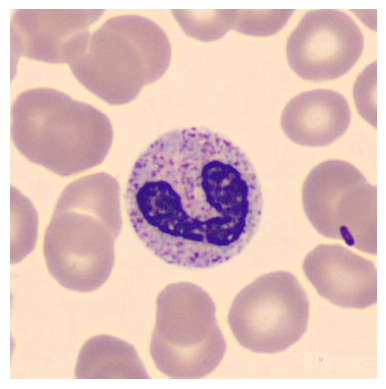

In [26]:

sample = train_df.iloc[0]

image = Image.open(sample["path"])
plt.imshow(image)
plt.axis("off")
plt.show()

In [20]:
image.size

(360, 363)

In [24]:
sizes = []

for path in train_df["path"].sample(100):

    img = Image.open(path)

    sizes.append(img.size)

pd.Series(sizes).value_counts()

(360, 363)    97
(366, 369)     3
Name: count, dtype: int64

img_name                                                       EO_985877.jpg
label                                                             Eosinophil
cell_size                                                                big
cell_shape                                                             round
nucleus_shape                                               unsegmented-band
nuclear_cytoplasmic_ratio                                                low
chromatin_density                                                    densely
cytoplasm_vacuole                                                         no
cytoplasm_texture                                                      clear
cytoplasm_colour                                                  light blue
granule_type                                                           round
granule_colour                                                           red
granularity                                                              yes

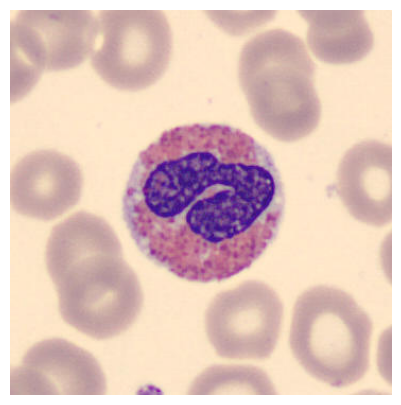

In [25]:
sample = train_df.sample(1).iloc[0]

image = Image.open(sample["path"])

plt.figure(figsize=(5,5))

plt.imshow(image)

plt.axis("off")

print(sample)

In [33]:
sizes = []

for path in train_df["path"]:

    img = Image.open(path)

    sizes.append(img.size)

pd.Series(sizes).value_counts()

(360, 363)    6018
(366, 369)     151
Name: count, dtype: int64

In [31]:
train_df["img_name"].duplicated().sum()

0

In [32]:
train_df.duplicated().sum()

0

In [34]:
for col in attributes:
    print(f"{col}: {train_df[col].nunique()} classes")
    print(sorted(train_df[col].unique()))
    print("-" * 50)

cell_size: 2 classes
['big', 'small']
--------------------------------------------------
cell_shape: 2 classes
['irregular', 'round']
--------------------------------------------------
nucleus_shape: 6 classes
['irregular', 'segmented-bilobed', 'segmented-multilobed', 'unsegmented-band', 'unsegmented-indented', 'unsegmented-round']
--------------------------------------------------
nuclear_cytoplasmic_ratio: 2 classes
['high', 'low']
--------------------------------------------------
chromatin_density: 2 classes
['densely', 'loosely']
--------------------------------------------------
cytoplasm_vacuole: 2 classes
['no', 'yes']
--------------------------------------------------
cytoplasm_texture: 2 classes
['clear', 'frosted']
--------------------------------------------------
cytoplasm_colour: 3 classes
['blue', 'light blue', 'purple blue']
--------------------------------------------------
granule_type: 4 classes
['coarse', 'nil', 'round', 'small']
------------------------------------

In [35]:
print(sorted(train_df["granule_type"].unique()))
print(sorted(train_df["granule_colour"].unique()))

['coarse', 'nil', 'round', 'small']
['nil', 'pink', 'purple', 'red']


# Dataset Analysis Report

## Project

**Explainable White Blood Cell Morphology Analysis using MAL-ViT**

---

# Purpose

The purpose of this analysis is to understand the WBCAtt dataset before developing the data pipeline and implementing the MAL-ViT model. This analysis verifies the dataset structure, annotation quality, image properties, and morphology attributes to ensure the dataset is suitable for multi-attribute learning.

---

# Dataset Information

## Dataset Name

**WBCAtt (White Blood Cell Attribute Dataset)**

The dataset contains microscopic peripheral blood cell images together with white blood cell subtype labels and multiple morphology attribute annotations.

---

# Dataset Split

The dataset is already divided into training, validation, and testing subsets.

| Split | Number of Images |
|--------|-----------------:|
| Training | 6,169 |
| Validation | 1,030 |
| Testing | 3,099 |
| **Total** | **10,298** |

The predefined split will be used throughout the project to ensure reproducible experiments.

---

# White Blood Cell Classes

The dataset contains **8 white blood cell categories**.

| Class |
|--------|
| Basophil |
| Eosinophil |
| Erythroblast |
| IG (Immature Granulocyte) |
| Lymphocyte |
| Monocyte |
| Neutrophil |
| Platelet |

---

# Dataset Structure

The dataset consists of three annotation files:

- `pbc_attr_v1_train.xlsx`
- `pbc_attr_v1_val.xlsx`
- `test.xlsx`

Each annotation file contains metadata describing every image.

The corresponding microscopic images are stored inside the `PBC_dataset_normal_DIB` directory, where images are organized into folders according to their white blood cell subtype.

---

# Dataset Columns

Each annotation contains the following information:

| Column | Description |
|---------|-------------|
| img_name | Image filename |
| label | White blood cell subtype |
| cell_size | Morphology attribute |
| cell_shape | Morphology attribute |
| nucleus_shape | Morphology attribute |
| nuclear_cytoplasmic_ratio | Morphology attribute |
| chromatin_density | Morphology attribute |
| cytoplasm_vacuole | Morphology attribute |
| cytoplasm_texture | Morphology attribute |
| cytoplasm_colour | Morphology attribute |
| granule_type | Morphology attribute |
| granule_colour | Morphology attribute |
| granularity | Morphology attribute |
| path | Complete image path |

---

# Morphology Attributes

The dataset provides **11 clinically meaningful morphology attributes**.

| Attribute | Number of Classes | Categories |
|------------|------------------:|-----------|
| cell_size | 2 | big, small |
| cell_shape | 2 | irregular, round |
| nucleus_shape | 6 | irregular, segmented-bilobed, segmented-multilobed, unsegmented-band, unsegmented-indented, unsegmented-round |
| nuclear_cytoplasmic_ratio | 2 | high, low |
| chromatin_density | 2 | densely, loosely |
| cytoplasm_vacuole | 2 | no, yes |
| cytoplasm_texture | 2 | clear, frosted |
| cytoplasm_colour | 3 | blue, light blue, purple blue |
| granule_type | 4 | coarse, nil, round, small |
| granule_colour | 4 | nil, pink, purple, red |
| granularity | 2 | no, yes |

These morphology attributes form the basis of the multi-attribute learning framework used by MAL-ViT.

---

# Data Quality Assessment

## Missing Values

No missing values were found in the dataset.

**Result**

✅ Dataset is complete.

---

## Duplicate Rows

No duplicate rows were detected.

**Result**

✅ Dataset is free from duplicated annotations.

---

## Duplicate Image Names

No duplicate image names were found.

**Result**

✅ Every image has a unique identifier.

---

# Image Analysis

## Image Format

The dataset images are stored in **RGB** format.

**Result**

✅ Suitable for Vision Transformer models.

---

## Image Resolution

Two image resolutions were observed.

| Resolution |
|------------|
| 360 × 363 |
| 366 × 369 |

Although two resolutions exist, they are very similar. All images will be resized to a fixed input size during preprocessing before training.

---

# Image Paths

The image paths provided in the annotation files were successfully verified.

Images can be loaded directly using the `path` column.

**Result**

✅ Image paths are valid.

---

# Dataset Readiness

The dataset satisfies all requirements for model development.

| Verification | Status |
|--------------|--------|
| Dataset loaded successfully | ✅ |
| Train/Validation/Test split verified | ✅ |
| Annotation files verified | ✅ |
| Image paths verified | ✅ |
| Images loaded successfully | ✅ |
| RGB images | ✅ |
| Missing values checked | ✅ |
| Duplicate rows checked | ✅ |
| Duplicate image names checked | ✅ |
| Morphology attributes verified | ✅ |

---

# Implications for MAL-ViT

The dataset is suitable for implementing the MAL-ViT architecture because it provides:

- White blood cell subtype labels.
- Multiple morphology attribute annotations.
- High-quality microscopic images.
- Predefined training, validation, and testing splits.

The model will learn multiple prediction tasks simultaneously:

1. White Blood Cell Subtype Classification (8 classes)
2. Cell Size Classification
3. Cell Shape Classification
4. Nucleus Shape Classification
5. Nuclear-to-Cytoplasmic Ratio Classification
6. Chromatin Density Classification
7. Cytoplasm Vacuole Classification
8. Cytoplasm Texture Classification
9. Cytoplasm Colour Classification
10. Granule Type Classification
11. Granule Colour Classification
12. Granularity Classification

This makes the project a **multi-task, multi-attribute classification problem**, where morphology attribute learning supports the final white blood cell subtype prediction.

---

# Conclusion

The exploratory analysis confirms that the WBCAtt dataset is clean, well-structured, and suitable for implementing MAL-ViT. The dataset contains high-quality image annotations, clinically meaningful morphology attributes, and predefined data splits, making it appropriate for reproducible experiments in explainable white blood cell morphology analysis.

With the dataset exploration complete, the next phase of the project will focus on developing the data pipeline, including label encoding, image preprocessing, custom PyTorch dataset implementation, and data loaders for model training.